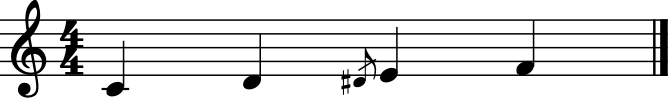

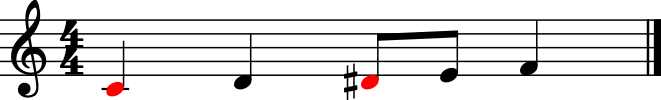

{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.meter.TimeSignature 4/4>
    {0.0} <music21.note.Note C>
    {1.0} <music21.note.Note D>
    {2.0} <music21.note.Note D#>
    {2.5} <music21.note.Note E>
    {3.0} <music21.note.Note F>
    {4.0} <music21.bar.Barline type=final>


In [25]:
from music21 import stream, note, chord, duration, converter,figuredBass
import copy

# -----------------------
# 工具/辅助函数
# -----------------------


def _ist_note_like(e):
    return isinstance(e, (note.Note, chord.Chord, note.Unpitched))


def _passender_container(e):
    for cls in (stream.Voice, stream.Measure, stream.Part, stream.Stream):
        ctx = e.getContextByClass(cls)
        if ctx is not None:
            return ctx
    return e.activeSite


def _naechstes_hauptelement(container, start_elem):
    start_off = start_elem.getOffsetBySite(container)
    seen = False
    for e in container.recurse().notesAndRests:
        off = e.getOffsetBySite(container)
        if e is start_elem:
            seen = True
            continue
        if seen and (_ist_note_like(e) or e.isRest):
            return e
    return None


def verzierungsnoten_umwandeln_fuer_analyse(
    stream_objekt,
    anteil_von_haupt=0.5,
    zeit_von_hauptnote_stehlen=True,
    hauptnote_verschieben=True,
    epsilon=1e-6,
    platzierung='gleich'
):
    """
    Nimmt eine Partitur, macht eine *Kopie* und wandelt in dieser Kopie
    Grace-Notes in normale Noten um.

    Die originale Partitur bleibt unverändert und kann wie gewohnt angezeigt werden.
    """
    # 🔸 WICHTIG: Kopie erzeugen
    s = copy.deepcopy(stream_objekt)

    graces = [n for n in s.recurse().notes if getattr(n.duration, "isGrace", False)]
    done = set()

    for g in graces:
        if g in done:
            continue

        cont = _passender_container(g)
        nxt = _naechstes_hauptelement(cont, g)
        if cont is None or nxt is None:
            continue

        off_g = g.getOffsetBySite(cont)
        off_nxt = nxt.getOffsetBySite(cont)

        # gleiche offset-Gruppe
        gruppe = [
            e for e in cont.getElementsByOffset(off_nxt, off_nxt, includeEndBoundary=True)
            if hasattr(e, "duration") and getattr(e.duration, "isGrace", False)
        ]

        if not gruppe:
            continue

        nxt_qL = float(nxt.duration.quarterLength)
        total = nxt_qL * anteil_von_haupt
        total = min(total, max(0.0, nxt_qL - epsilon))
        per = total / len(gruppe)

        if platzierung == 'gleich':
            start = off_nxt
            ziel_haupt = off_nxt + total
        else:  # 'vor'
            start = off_nxt - total
            ziel_haupt = off_nxt

        pos = start
        for gr in gruppe:
            # 👉 Grace-Flag weg, echte Dauer
            gr.duration = duration.Duration(per)
            cont.remove(gr, recurse=False)
            cont.insert(pos, gr)
            pos += per
            done.add(gr)

        if hauptnote_verschieben:
            cont.remove(nxt, recurse=False)
            cont.insert(ziel_haupt, nxt)

        if zeit_von_hauptnote_stehlen and not nxt.isRest:
            nxt.duration.quarterLength = max(epsilon, nxt_qL - total)

    return s
# -----------------------
# 你的示例
# -----------------------
# Dummy-Stream

s = converter.parse('tinyNotation: 4/4 c4 d4 e4 f4')
m1 = s.measure(1)

g = note.Note('D#4')
g.duration = duration.GraceDuration()
m1.insert(2.0, g)  # Grace-Note auf dem selben Offset wie e4 (2.0)

# --- Analyse-Stream erzeugen ------------------------------------
analyse = verzierungsnoten_umwandeln_fuer_analyse(
    s,
    anteil_von_haupt=0.5,     # Gesamt-Dauer der Verzierungsnoten = 1/2 der Hauptnote
    platzierung='gleich',     # Verzierungsnoten beginnen auf der Position der Hauptnote
    zeit_von_hauptnote_stehlen=True,
    hauptnote_verschieben=True
)

# --- Noten im Analyse-Stream mit Offset 0.0 und 2.0 rot färben ---
rote_offsets = {0.0, 2.0}

for n in analyse.recurse().notes:
    # kleine Rundung gegen Floating-Point-Effekte
    if round(float(n.offset), 6) in rote_offsets:
        n.style.color = 'red'

# --- Anzeigen ----------------------------------------------------
# Original-Partitur: Grace-Note bleibt klein, alles unverändert
s.show()

# Analyse-Stream: Grace-Note jetzt normale Note mit Dauer/Offset, rot markiert
analyse.show()
analyse.show('text')

In [17]:
from music21 import chord,interval,note

def Intervalls_von_Basston_im_Akkord(ch):
    bass = ch.bass()
    pitches = sorted(ch.pitches, key=lambda p: p.ps)
    return [interval.Interval(bass, p) for p in pitches if p != bass]

# （1）定义映射表
Generalbass= {
    ('major seventh chord', 0): "G7", ('major seventh chord', 1): "G56",  ('major seventh chord', 2): "G34",  ('major seventh chord', 3): "G24",
    ('dominant seventh chord', 0): "D7", ('dominant seventh chord', 1): "D56", ('dominant seventh chord', 2): "D34", ('dominant seventh chord', 3): "G24",
    ('minor seventh chord', 0): "K7", ('minor seventh chord', 1): "K56", ('minor seventh chord', 2): "K34", ('minor seventh chord', 3): "K24",
    ('half-diminished seventh chord', 0): "H7", ('half-diminished seventh chord', 1): "H56", ('half-diminished seventh chord', 2): "H34", ('half-diminished seventh chord', 3): "H24",
    ('diminished seventh chord', 0): "V7", ('diminished seventh chord', 1): "V56", ('diminished seventh chord', 2): "V34", ('diminished seventh chord', 3): "V24"
}
#（2）你的和弦
c1 = chord.Chord(["C4","D-4","G-4"])
cloosde = c1.closedPosition()

c2=interval.Interval(note.Note("D3"),note.Note("c4"))
c1_Intervalle=Intervalls_von_Basston_im_Akkord(cloosde)
Basston=cloosde.bass()
c3 = note.Note("C1")
c3._getMeasureOffset()
Aa=[i.generic.value for i in c1_Intervalle]
name = c1.commonName        # 'major seventh chord'
inv = c1.inversion()        # 0
Terz = note.Note(c1.third) if c1.third else None   
Grundton = note.Note(c1.root()) if c1.root() else None     
Septime = note.Note(c1.seventh) if c1.seventh else None  

name1=cloosde.commonName 
a = (name,name1, inv)   
Akkordtöne = cloosde.notes
Überprüfung = False
if Aa == [2, 5]:
    Überprüfung = True
print(c1.isChord)
#（3）查字典
#symbol = Generalbass.get(a, "Unbekannt")  # 若找不到给默认
print(c1_Intervalle)
print(Überprüfung)
#展示和弦
c2.generic

True
[<music21.interval.Interval m2>, <music21.interval.Interval d5>]
True


<music21.interval.GenericInterval 7>

In [ ]:
from music21 import note,chord,interval

n = note.Note('C4')
target = note.Note('E4')
c1 = chord.Chord(["C4","E-3","G3","F4","B2"])
while n.pitch.midi <= target.pitch.midi:
    n.pitch.octave += 1
n1 = note.Note("C4")
n2 = note.Note("E5")
iv = interval.Interval(n1, n2)
Basston = note.Note(c1.bass()) if c1.bass() else None

print(c1.intervalFromChordStep(4))

False


In [1]:
from music21 import note, chord, interval

c = interval.Interval(note.Note("E3"), note.Note("A4"))
print(c.isConsonant())


False


In [29]:
from music21 import note, chord, interval


def classify_dissonant_harmony(Objekt,
    Annotationskennzeichen=None,
):
    result = {
        'dissonanter_Akkord': False,
        'category': None,
        'qualität': None,
        'dissonant_notes': [],
        'root': None,
        'pcset': set(),
        'akkordtöne': set(),
        'chord': None,
    }
    
    if not isinstance(Objekt, chord.Chord):
        raise TypeError
    
    Akkord = Objekt.closedPosition()
    Akkordtöne = list(Akkord.notes)
    Alle_Akkordtöne=list(Objekt.notes)
    Qualität = Objekt.commonName
    Umkehrung = Akkord.inversion()

    result['chord'] = Akkord

    
    pcs_abs = {n.pitch.pitchClass for n in Alle_Akkordtöne if isinstance(n, note.Note)}
    result['pcset'] = pcs_abs
    Töne_name = {n.name for n in Akkordtöne if isinstance(n, note.Note)}
    result['akkordtöne'] = Töne_name 
    
    Grundton = note.Note(Objekt.root()) if Objekt.root() else None
    Terz = note.Note(Objekt.third) if Objekt.third else None
    Quinte = note.Note(Objekt.fifth) if Objekt.fifth else None
    Septime = note.Note(Objekt.seventh) if Objekt.seventh else None
    result['Parnerton'] = Grundton
    oberste_note = max(Alle_Akkordtöne, key=lambda n: n.pitch.midi)

    
    
    if len(Akkordtöne) == 4:
        if Grundton and Terz and Quinte and Septime:
            result['dissonanter_Akkord'] = True
            result['category'] = 'Septakkord'
            print(Qualität )
            if Qualität in ('major seventh chord', 'dominant seventh chord','minor seventh chord','minor-augmented tetrachord'):
                if Umkehrung != 2:
                    result['dissonant_notes'] = [Septime]
                if Umkehrung == 2:
                    if Annotationskennzeichen and Annotationskennzeichen=='D.G.':
                        result['dissonant_notes'] = [Grundton,Septime]
                    else:
                        result['dissonant_notes'] = [Quinte,Septime]
            elif Qualität in ('diminished seventh chord','half-diminished seventh chord'):
                result['dissonant_notes'] = [Quinte,Septime]
            else:
                result['dissonant_notes'] = [Septime]
                result['category'] = 'Unbekannter_Septakkord'
        else:
            return result
    
    if len(Akkordtöne) == 3:
        if Akkord.isTriad(): 
            if Qualität in ('diminished triad', 'augmented triad'):
                result['dissonanter_Akkord'] = True
                result['dissonant_notes'] = [Quinte]
                if Qualität == 'diminished triad':
                    result['category'] = 'verminderter Dreiklang'
                if Qualität == 'augmented triad':
                    result['category'] =  'übermäßiger Dreiklang'
            
            elif Qualität in ('major triad', 'minor triad') and Umkehrung != 2:
                result['dissonanter_Akkord'] = True
                result['category'] = 'Quartsextakkord'
                if Annotationskennzeichen=='D.G.':
                    result['dissonant_notes'] = [Grundton]
                else:
                    result['dissonant_notes'] = [Quinte]
            else:
                result['dissonant_notes'] = [Quinte]
                result['category'] = 'Unbekannter_Dreiklang'

        elif Septime and Grundton and (Terz or Quinte):
            result['dissonanter_Akkord'] = True
            result['category'] = 'unvollständigen Septakkord'
            if Terz:
                if Qualität in ('incomplete major-seventh chord','incomplete dominant-seventh chord','incomplete minor-seventh chord'):
                    result['dissonant_notes'] = [Septime]
                elif Qualität == 'enharmonic equivalent to diminished triad':
                    result['dissonant_notes'] = [Quinte,Septime]
                else:
                    result['dissonant_notes'] = [Septime]
                    result['category'] = 'Unbekannter_Dreiklang'
            if Quinte:
                if Qualität in ('incomplete major-seventh chord','incomplete dominant-seventh chord'):
                    if Umkehrung != 2:
                        result['dissonant_notes'] = [Septime]
                    else:
                        if Annotationskennzeichen and Annotationskennzeichen=='D.G.':
                            result['dissonant_notes'] = [Grundton,Septime]
                        else:
                            result['dissonant_notes'] = [Quinte,Septime]
                elif Qualität in ('incomplete half-diminished seventh chord','enharmonic equivalent to diminished triad'):
                    result['dissonant_notes'] = [Quinte,Septime]
                else:
                    result['dissonant_notes'] = [Septime]
                    result['category'] = 'Unbekannter_Dreiklang'
        else:
            return result
    
    durations = {n.quarterLength for n in Alle_Akkordtöne}
    if len(Akkordtöne) == 2 and len(durations) == 1:
        iv = interval.Interval(Akkordtöne[0], Akkordtöne[1])
        simp = iv.simpleName
        if simp in ('A4', 'd5'):
            result['dissonanter_Akkord'] = True
            result['category'] = 'Tritonus'
            if simp == 'A4':
                dis = Akkordtöne[0] if Akkordtöne[0].pitch.midi <= Akkordtöne[1].pitch.midi else Akkordtöne[1]
            else:
                dis = Akkordtöne[0] if Akkordtöne[0].pitch.midi > Akkordtöne[1].pitch.midi else Akkordtöne[1]
            result['dissonant_notes'] = [dis]
            return result

        elif iv.name in ('m9','M9'):
            result['dissonanter_Akkord'] = True
            result['category'] = 'Noneakkord'
            dis = Akkordtöne[0] if Akkordtöne[0].pitch.midi > Akkordtöne[1].pitch.midi else Akkordtöne[1]
            result['dissonant_notes'] = [dis]
            return result


    return result

c = chord.Chord(["E3","G4","A-6","B-7"])
s7=note.Note(c.seventh) if c.seventh else None
print(c.root(),c.third,c.fifth,note.Note(c.seventh))
print(classify_dissonant_harmony(c))


E3 G4 B-7 <music21.note.Note C>
{'dissonanter_Akkord': False, 'category': None, 'qualität': None, 'dissonant_notes': [], 'root': None, 'pcset': {8, 10, 4, 7}, 'akkordtöne': {'B-', 'G', 'E', 'A-'}, 'chord': <music21.chord.Chord E3 G3 A-3 B-3>, 'Parnerton': <music21.note.Note E>}


In [30]:
from music21 import chord,note
print(chord.Chord(["A2","C3","D3","F#4"]).commonName)
x = note.Note(None)
print(x)  

dominant seventh chord
<music21.note.Note C>
